# Exploratory Data Analysis of a parquet file

In [ ]:
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
import plotly.graph_objects as go

In [2]:
file_path = "/run/media/francesco/STORAGE/Coll_2v_VBFHbb_preliminary_prove/Train/VBFHbb-NEVENT10000-RS35000001.parquet"

parquet_file = pq.read_schema(file_path)

We can look at the columns in the files

In [3]:
parquet_file.names

['FullReco_PUPPIPart_PT',
 'FullReco_PUPPIPart_Eta',
 'FullReco_PUPPIPart_Phi',
 'FullReco_PUPPIPart_E',
 'FullReco_PUPPIPart_Charge',
 'FullReco_PUPPIPart_Mass',
 'FullReco_PUPPIPart_PID',
 'FullReco_PUPPIPart_D0',
 'FullReco_PUPPIPart_DZ',
 'FullReco_PUPPIPart_ErrorD0',
 'FullReco_PUPPIPart_ErrorDZ',
 'FullReco_PUPPIPart_fUniqueID',
 'FullReco_PUPPIPart_PuppiW',
 'FullReco_PUPPIPart_IsPU',
 'FullReco_PUPPIPart_IsRecoPU',
 'FullReco_PFPart_PT',
 'FullReco_PFPart_Eta',
 'FullReco_PFPart_Phi',
 'FullReco_PFPart_E',
 'FullReco_PFPart_Charge',
 'FullReco_PFPart_Mass',
 'FullReco_PFPart_PID',
 'FullReco_PFPart_D0',
 'FullReco_PFPart_DZ',
 'FullReco_PFPart_ErrorD0',
 'FullReco_PFPart_ErrorDZ',
 'FullReco_PFPart_fUniqueID',
 'FullReco_PFPart_PuppiW',
 'FullReco_PFPart_IsPU',
 'FullReco_PFPart_IsRecoPU',
 'FullReco_Electron_PT',
 'FullReco_Electron_Eta',
 'FullReco_Electron_Phi',
 'FullReco_Electron_Charge',
 'FullReco_Electron_EhadOverEem',
 'FullReco_Electron_IsolationVar',
 'FullReco_Elect

We are interested in L1-trigger data, in particular we focus on pT, Eta and Phi features

In [4]:
table = pq.read_table(file_path, columns=["L1T_PUPPIPart_PT", "L1T_PUPPIPart_Eta", "L1T_PUPPIPart_Phi"])

df = table.to_pandas()

df.head()

,L1T_PUPPIPart_PT,L1T_PUPPIPart_Eta,L1T_PUPPIPart_Phi
0,"[17.94, 16.19, 15.8, 13.97, 10.74, 10.19, 10.0...","[-2.87, -0.791, 0.9727, 0.6577, 3.232, -0.806,...","[-2.418, -1.156, 1.052, 2.291, 0.895, 1.661, 1..."
1,"[72.75, 65.56, 60.9, 55.62, 51.25, 25.83, 21.6...","[1.582, 1.583, 3.342, -2.379, 1.589, 1.598, -2...","[-0.4468, -0.4458, -1.563, 2.213, -0.4531, -0...."
2,"[32.38, 30.73, 29.36, 20.28, 19.47, 15.03, 14....","[-0.4497, -1.826, -0.44, -0.05414, 1.169, -0.4...","[0.788, -1.883, 0.747, -2.828, 3.094, 0.775, 0..."
3,"[41.88, 17.88, 13.92, 13.8, 11.67, 11.46, 11.4...","[-1.7, 2.576, 2.576, 1.666, -4.37, 0.07336, -4...","[1.438, -1.154, -1.181, -0.3948, -1.115, -0.29..."
4,"[42.8, 37.56, 22.11, 19.08, 18.28, 18.14, 14.5...","[-0.2761, -0.2007, -0.02496, 4.824, 3.105, 4.7...","[2.92, 2.898, 0.12476, -3.07, 0.1993, -2.994, ..."


In [5]:
print(f'Num_events:{len(df["L1T_PUPPIPart_PT"])}')
print(f'Num_elem_per_event:{len(df["L1T_PUPPIPart_PT"][0])}')

Num_events:8660
Num_elem_per_event:1000


In [6]:
ak_array = ak.from_arrow(table)
print(ak_array.type)

8660 * struct[{L1T_PUPPIPart_PT: var * float16, L1T_PUPPIPart_Eta: var * float16, L1T_PUPPIPart_Phi: var * float16}, parameters={"__metadata__": {"source_root": "/pool/condor/dir_2700345/tmpdir/Events/run_01/WJets_delphes_events.root", "nEvents": "8660"}}]


In [7]:
pt_all = ak.flatten(ak_array["L1T_PUPPIPart_PT"])
eta_all = ak.flatten(ak_array["L1T_PUPPIPart_Eta"])
phi_all = ak.flatten(ak_array["L1T_PUPPIPart_Phi"])

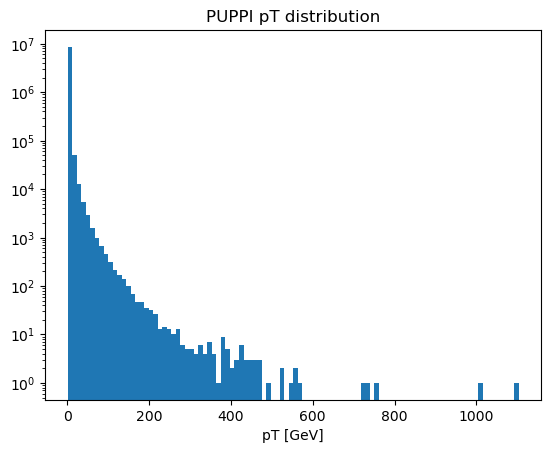

In [8]:
plt.hist(pt_all, bins=100)
plt.xlabel("pT [GeV]")
plt.yscale("log")
plt.title("PUPPI pT distribution")

plt.show()

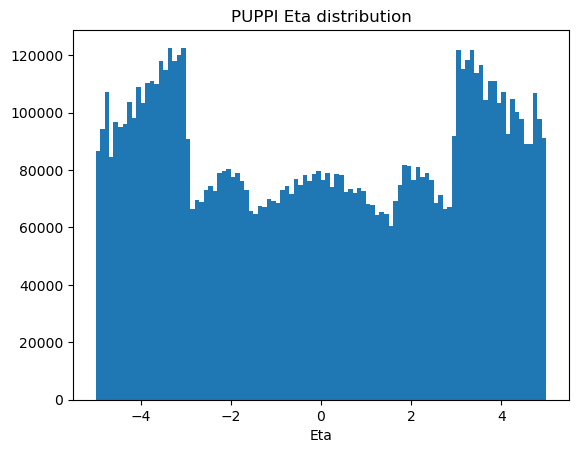

In [9]:
plt.hist(eta_all, bins=100)
plt.xlabel("Eta")
plt.title("PUPPI Eta distribution")

plt.show()

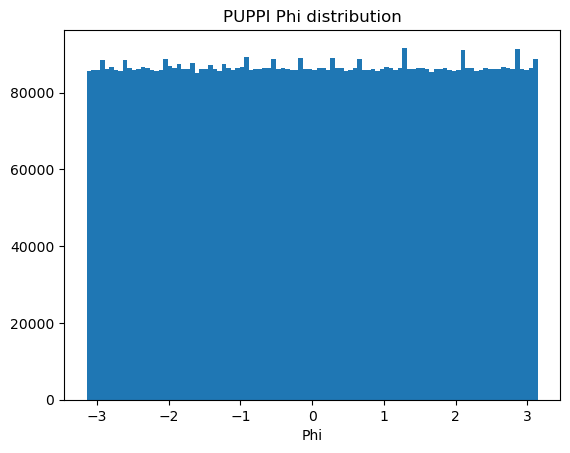

In [10]:
plt.hist(phi_all, bins=100)
plt.xlabel("Phi")
plt.title("PUPPI Phi distribution")

plt.show()

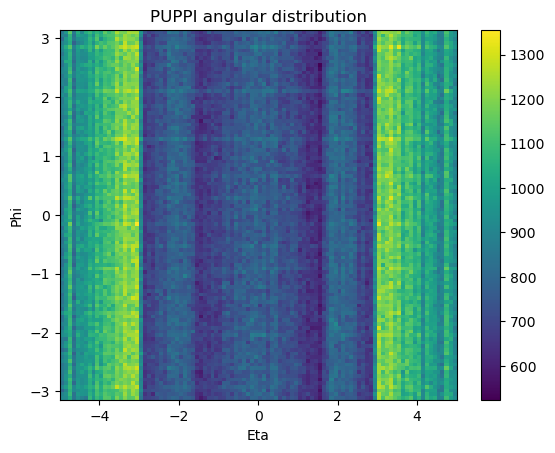

In [11]:
plt.hist2d(ak.to_numpy(eta_all), ak.to_numpy(phi_all), bins=100)

plt.xlabel("Eta")
plt.ylabel("Phi")
plt.colorbar()
plt.title("PUPPI angular distribution")

plt.show()

In [ ]:
#Select an event
event = ak_array[0] 

pt = ak.to_numpy(event["L1T_PUPPIPart_PT"])
eta = ak.to_numpy(event["L1T_PUPPIPart_Eta"])
phi = ak.to_numpy(event["L1T_PUPPIPart_Phi"])

#Coordinates
px = pt * np.cos(phi)
py = pt * np.sin(phi)
pz = pt * np.sinh(eta)

#Normalization for visualization
norm = np.sqrt(px**2 + py**2 + pz**2) + 1e-9
ux, uy, uz = px/norm, py/norm, pz/norm

#Lines length proportional to pT
scale = pt  

x_end = ux * scale
y_end = uy * scale
z_end = uz * scale

#Origin (Vertex)
x0 = np.zeros_like(x_end)
y0 = np.zeros_like(y_end)
z0 = np.zeros_like(z_end)

fig = go.Figure()

for i in range(len(x_end)):
    fig.add_trace(go.Scatter3d(
        x=[x0[i], x_end[i]],
        y=[y0[i], y_end[i]],
        z=[z0[i], z_end[i]],
        mode="lines",
        line=dict(width=2),
        name=f"particle {i}"
    ))

fig.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z (beam)"
    ),
    title="PUPPI Event Display 3D",
)

fig.show()


/tmp/ipykernel_25318/3714431491.py:18: RuntimeWarning: overflow encountered in square
  norm = np.sqrt(px**2 + py**2 + pz**2) + 1e-9
